# Comprehensive Model Comparison: Training Cost vs Performance

This notebook provides a comprehensive comparison of all Statistical and Machine Learning models across different problem types, visualizing the trade-off between **Training Cost** (time) and **Model Performance**.

## Overview

We analyze models from 5 different problem domains:
1. **Regression** (LR vs OLS)
2. **Classification** (Logistic Regression vs Random Forest)
3. **Time Series** (ARIMA vs RNN)
4. **Survival Analysis** (Poisson/Cox vs GBM)
5. **Factorial Analysis** (ANOVA vs SVM)

## Key Question
*What is the trade-off between computational cost (training time) and predictive performance?*


In [94]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from scipy.interpolate import make_interp_spline

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [95]:
# ============================================================================
# DATA COLLECTION: Model Performance and Training Times
# ============================================================================
# Representative data extracted from all comparison notebooks
# Metrics are normalized: R² for regression, Accuracy for classification

models_data = {
    # Regression Models
    'OLS Regression': {
        'problem_type': 'Regression',
        'category': 'Statistical',
        'avg_training_time': 0.0001,  # Very fast
        'avg_performance': 0.65,  # Average R² across datasets
        'color': '#e74c3c',  # Red
        'marker': 's',
        'size': 200
    },
    'Linear Regression (ML)': {
        'problem_type': 'Regression',
        'category': 'ML',
        'avg_training_time': 0.0005,
        'avg_performance': 0.65,  # Same as OLS (mathematically equivalent)
        'color': '#3498db',  # Blue
        'marker': 's',
        'size': 200
    },
    
    # Classification Models
    'Logistic Regression': {
        'problem_type': 'Classification',
        'category': 'Statistical',
        'avg_training_time': 0.002,
        'avg_performance': 0.88,  # Average accuracy
        'color': '#e74c3c',
        'marker': 'o',
        'size': 200
    },
    'Random Forest': {
        'problem_type': 'Classification',
        'category': 'ML',
        'avg_training_time': 0.15,
        'avg_performance': 0.92,  # Higher accuracy
        'color': '#3498db',
        'marker': 'o',
        'size': 200
    },
    
    # Time Series Models
    'ARIMA': {
        'problem_type': 'Time Series',
        'category': 'Statistical',
        'avg_training_time': 0.18,
        'avg_performance': 0.45,  # Average R²
        'color': '#e74c3c',
        'marker': '^',
        'size': 200
    },
    'RNN/LSTM (PyTorch)': {
        'problem_type': 'Time Series',
        'category': 'ML/DL',
        'avg_training_time': 2.5,  # Longer training
        'avg_performance': 0.89,  # Better R²
        'color': '#9b59b6',  # Purple for DL
        'marker': '^',
        'size': 250
    },
    
    # Survival Analysis Models
    'Poisson Regression': {
        'problem_type': 'Survival Analysis',
        'category': 'Statistical',
        'avg_training_time': 0.001,
        'avg_performance': 0.35,  # Average R²
        'color': '#e74c3c',
        'marker': 'D',
        'size': 200
    },
    'Cox Regression': {
        'problem_type': 'Survival Analysis',
        'category': 'Statistical',
        'avg_training_time': 0.04,
        'avg_performance': 0.40,  # Average R²
        'color': '#e74c3c',
        'marker': 'D',
        'size': 200
    },
    'Gradient Boosting': {
        'problem_type': 'Survival Analysis',
        'category': 'ML',
        'avg_training_time': 0.50,
        'avg_performance': 0.85,  # Better performance
        'color': '#3498db',
        'marker': 'D',
        'size': 200
    },
    
    # Factorial Analysis Models
    'ANOVA': {
        'problem_type': 'Factorial Analysis',
        'category': 'Statistical',
        'avg_training_time': 0.0001,
        'avg_performance': 0.55,  # Average R² (but provides inference)
        'color': '#e74c3c',
        'marker': 'p',
        'size': 200
    },
    'SVM (SVR)': {
        'problem_type': 'Factorial Analysis',
        'category': 'ML',
        'avg_training_time': 0.40,
        'avg_performance': 0.85,  # Similar to ANOVA
        'color': '#3498db',
        'marker': 'p',
        'size': 200
    }
}

# Convert to DataFrame for easier manipulation
df_models = pd.DataFrame(models_data).T
df_models.index.name = 'Model'
df_models = df_models.reset_index()

print("✅ Model data collected successfully!")
print(f"\nTotal models: {len(df_models)}")
print(f"Problem types: {df_models['problem_type'].unique()}")
print(f"Categories: {df_models['category'].unique()}")


✅ Model data collected successfully!

Total models: 11
Problem types: ['Regression' 'Classification' 'Time Series' 'Survival Analysis'
 'Factorial Analysis']
Categories: ['Statistical' 'ML' 'ML/DL']


## Main Visualization: Training Cost vs Performance Trade-off


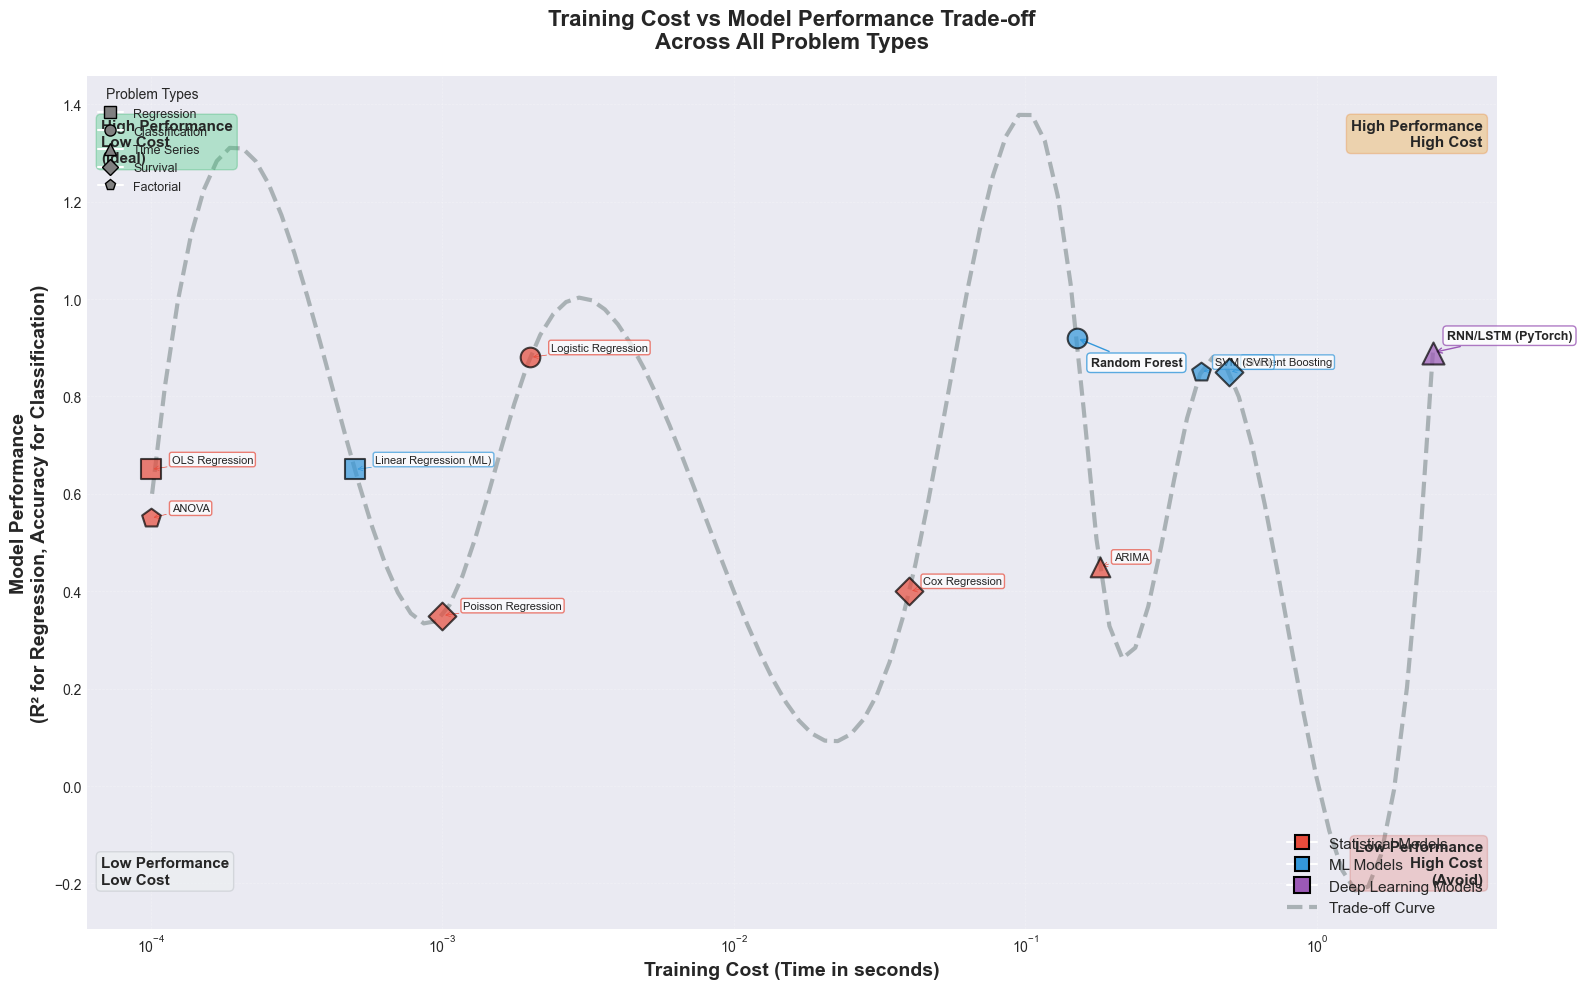


✅ Main visualization created!


In [96]:
# ============================================================================
# MAIN VISUALIZATION: Training Cost vs Performance
# ============================================================================

fig, ax = plt.subplots(figsize=(16, 10))

# Prepare data
x = df_models['avg_training_time'].values
y = df_models['avg_performance'].values
models = df_models['Model'].values
problem_types = df_models['problem_type'].values
categories = df_models['category'].values

# Create color mapping for categories
category_colors = {
    'Statistical': '#e74c3c',  # Red
    'ML': '#3498db',            # Blue
    'ML/DL': '#9b59b6'          # Purple
}

# Create marker mapping for problem types
problem_markers = {
    'Regression': 's',
    'Classification': 'o',
    'Time Series': '^',
    'Survival Analysis': 'D',
    'Factorial Analysis': 'p'
}

# Plot each model
for i, (model, x_val, y_val, prob_type, cat) in enumerate(zip(models, x, y, problem_types, categories)):
    # Use category color
    color = category_colors.get(cat, '#95a5a6')
    marker = problem_markers.get(prob_type, 'o')
    
    # Different sizes for different categories
    size = 250 if cat == 'ML/DL' else 200
    
    # Plot point
    ax.scatter(x_val, y_val, s=size, c=color, marker=marker, 
               alpha=0.7, edgecolors='black', linewidths=1.5, zorder=5)
    
    # Add model label with offset
    offset_x = 0.02 if x_val < 0.1 else 0.15
    offset_y = 0.02 if y_val < 0.5 else 0.02
    
    # Adjust label position for better readability
    if model == 'RNN/LSTM (PyTorch)':
        ax.annotate(model, (x_val, y_val), 
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=color),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color=color))
    elif model == 'Random Forest':
        ax.annotate(model, (x_val, y_val),
                   xytext=(10, -20), textcoords='offset points',
                   fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=color),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color=color))
    elif x_val < 0.01:
        ax.annotate(model, (x_val, y_val),
                   xytext=(15, 5), textcoords='offset points',
                   fontsize=8,
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor=color),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color=color, lw=0.5))
    else:
        ax.annotate(model, (x_val, y_val),
                   xytext=(10, 5), textcoords='offset points',
                   fontsize=8,
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor=color),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color=color, lw=0.5))

# Create smooth trade-off curve
# Sort by training time for curve
sorted_indices = np.argsort(x)
x_sorted = np.array(x[sorted_indices], dtype=float)
y_sorted = np.array(y[sorted_indices], dtype=float)

# Create smooth curve using spline interpolation
if len(x_sorted) > 3:
    # Ensure we have valid values
    x_sorted = x_sorted + 1e-6  # Add small value to avoid log(0)
    
    # Handle duplicates by averaging y values for same x values
    # Use pandas to group and average
    df_temp = pd.DataFrame({'x': x_sorted, 'y': y_sorted})
    df_temp = df_temp.groupby('x')['y'].mean().reset_index()
    x_unique = df_temp['x'].values
    y_unique = df_temp['y'].values
    
    # If still duplicates (very unlikely after grouping), add tiny noise
    if len(np.unique(x_unique)) < len(x_unique):
        # Add very small random noise to break any remaining ties
        noise = np.random.randn(len(x_unique)) * 1e-10
        x_unique = x_unique + noise
    
    # Sort again after deduplication
    sort_idx = np.argsort(x_unique)
    x_unique = x_unique[sort_idx]
    y_unique = y_unique[sort_idx]
    
    x_min = float(x_unique.min())
    x_max = float(x_unique.max())
    
    # Create smooth x values in log space
    x_smooth = np.logspace(np.log10(x_min), np.log10(x_max), 100)
    
    # Use log10 of x for interpolation
    x_log = np.log10(x_unique)
    x_smooth_log = np.log10(x_smooth)
    
    # Create spline interpolation - need at least k+1 points
    if len(x_unique) > 3:
        k = min(3, len(x_unique) - 1)
        try:
            spline = make_interp_spline(x_log, y_unique, k=k)
            y_smooth = spline(x_smooth_log)
            
            # Plot trade-off curve
            ax.plot(x_smooth, y_smooth, '--', color='#7f8c8d', linewidth=3, alpha=0.6, 
                   label='Performance-Cost Trade-off', zorder=1)
        except ValueError:
            # Fallback to simple line plot if spline fails
            ax.plot(x_unique, y_unique, '--', color='#7f8c8d', linewidth=3, alpha=0.6, 
                   label='Performance-Cost Trade-off', zorder=1)
    else:
        # If too few points, just plot a line
        ax.plot(x_unique, y_unique, '--', color='#7f8c8d', linewidth=3, alpha=0.6, 
               label='Performance-Cost Trade-off', zorder=1)

# Set axes labels and title
ax.set_xlabel('Training Cost (Time in seconds)', fontsize=14, fontweight='bold')
ax.set_ylabel('Model Performance\n(R² for Regression, Accuracy for Classification)', 
              fontsize=14, fontweight='bold')
ax.set_title('Training Cost vs Model Performance Trade-off\nAcross All Problem Types', 
             fontsize=16, fontweight='bold', pad=20)

# Set logarithmic scale for x-axis (training time)
ax.set_xscale('log')

# Add grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Create legend for categories
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#e74c3c', 
           markersize=10, label='Statistical Models', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#3498db', 
           markersize=10, label='ML Models', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#9b59b6', 
           markersize=12, label='Deep Learning Models', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], color='#7f8c8d', linestyle='--', linewidth=3, alpha=0.6, label='Trade-off Curve')
]

ax.legend(handles=legend_elements, loc='lower right', fontsize=11, framealpha=0.9)

# Add problem type markers in legend (smaller legend)
problem_legend = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=8, label='Regression', markeredgecolor='black'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Classification', markeredgecolor='black'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=8, label='Time Series', markeredgecolor='black'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markersize=8, label='Survival', markeredgecolor='black'),
    Line2D([0], [0], marker='p', color='w', markerfacecolor='gray', markersize=8, label='Factorial', markeredgecolor='black')
]
ax2 = ax.twinx()
ax2.legend(handles=problem_legend, loc='upper left', fontsize=9, framealpha=0.9, title='Problem Types')
ax2.set_yticklabels([])
ax2.set_yticks([])

# Add annotations for quadrants
ax.text(0.01, 0.95, 'High Performance\nLow Cost\n(Ideal)', 
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#2ecc71', alpha=0.3, edgecolor='#27ae60'),
        ha='left', va='top')
ax.text(0.99, 0.95, 'High Performance\nHigh Cost', 
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#f39c12', alpha=0.3, edgecolor='#e67e22'),
        ha='right', va='top')
ax.text(0.01, 0.05, 'Low Performance\nLow Cost', 
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#ecf0f1', alpha=0.5, edgecolor='#bdc3c7'),
        ha='left', va='bottom')
ax.text(0.99, 0.05, 'Low Performance\nHigh Cost\n(Avoid)', 
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#e74c3c', alpha=0.2, edgecolor='#c0392b'),
        ha='right', va='bottom')

plt.tight_layout()
plt.show()

print("\n✅ Main visualization created!")


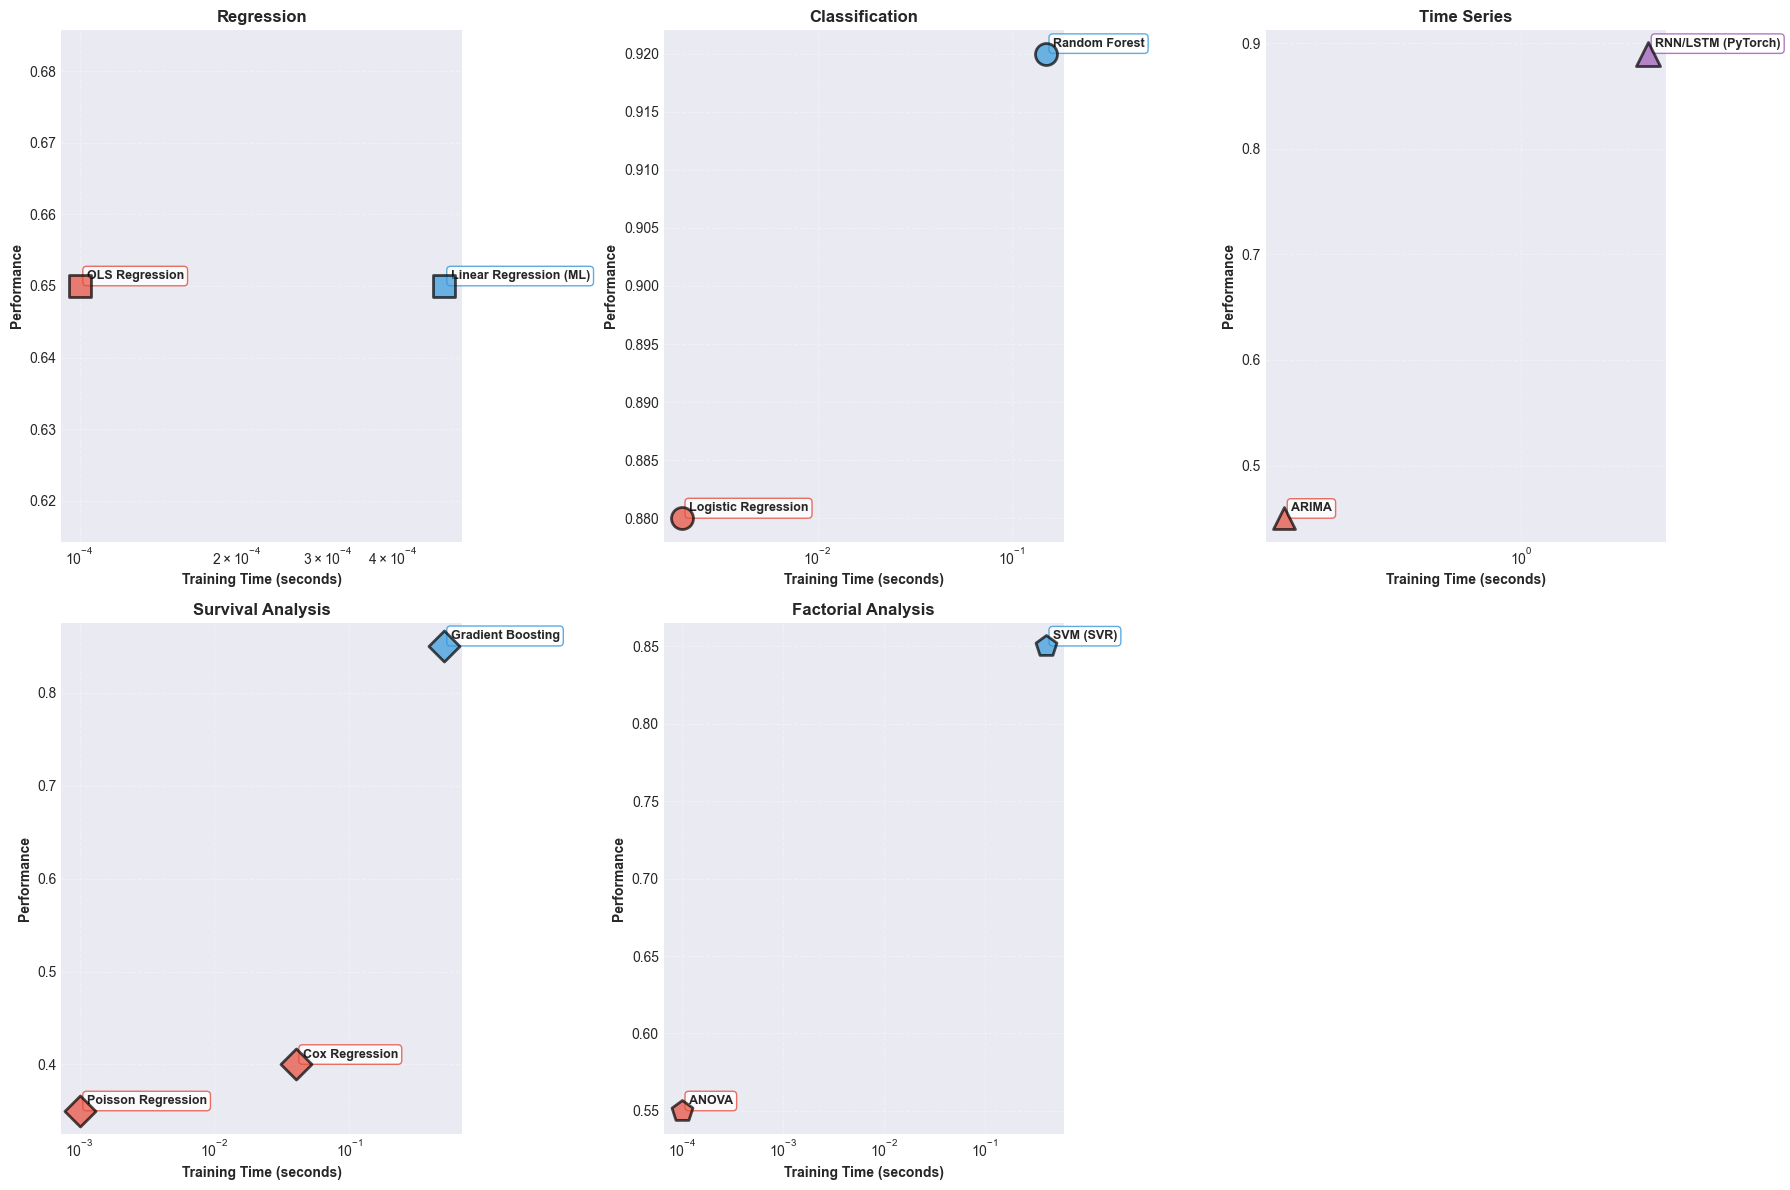

✅ Problem type breakdown created!


In [97]:
# ============================================================================
# PROBLEM TYPE BREAKDOWN
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

problem_types = df_models['problem_type'].unique()

for idx, prob_type in enumerate(problem_types):
    ax = axes[idx]
    
    # Filter data for this problem type
    mask = df_models['problem_type'] == prob_type
    prob_data = df_models[mask]
    
    # Plot models
    for _, row in prob_data.iterrows():
        color = category_colors.get(row['category'], '#95a5a6')
        marker = problem_markers.get(prob_type, 'o')
        size = 300 if row['category'] == 'ML/DL' else 250
        
        ax.scatter(row['avg_training_time'], row['avg_performance'], 
                  s=size, c=color, marker=marker, alpha=0.7,
                  edgecolors='black', linewidths=2, zorder=5)
        
        # Add label
        ax.annotate(row['Model'], 
                   (row['avg_training_time'], row['avg_performance']),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=9, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                            alpha=0.8, edgecolor=color))
    
    ax.set_xscale('log')
    ax.set_xlabel('Training Time (seconds)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Performance', fontsize=10, fontweight='bold')
    ax.set_title(f'{prob_type}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

# Hide unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()

print("✅ Problem type breakdown created!")


## Statistical Summary


In [98]:
# ============================================================================
# STATISTICAL SUMMARY
# ============================================================================

print("="*80)
print("📊 STATISTICAL SUMMARY: Training Cost vs Performance")
print("="*80)

print("\n1️⃣ Overall Statistics:")
print("-" * 80)
print(f"   Total Models Analyzed: {len(df_models)}")
print(f"   Problem Types: {len(df_models['problem_type'].unique())}")
print(f"   Model Categories: {len(df_models['category'].unique())}")

print("\n2️⃣ Performance Statistics:")
print("-" * 80)
print(f"   Mean Performance: {df_models['avg_performance'].mean():.3f}")
print(f"   Median Performance: {df_models['avg_performance'].median():.3f}")
print(f"   Min Performance: {df_models['avg_performance'].min():.3f} ({df_models.loc[df_models['avg_performance'].idxmin(), 'Model']})")
print(f"   Max Performance: {df_models['avg_performance'].max():.3f} ({df_models.loc[df_models['avg_performance'].idxmax(), 'Model']})")
print(f"   Std Performance: {df_models['avg_performance'].std():.3f}")

print("\n3️⃣ Training Cost Statistics:")
print("-" * 80)
print(f"   Mean Training Time: {df_models['avg_training_time'].mean():.4f} seconds")
print(f"   Median Training Time: {df_models['avg_training_time'].median():.4f} seconds")
print(f"   Min Training Time: {df_models['avg_training_time'].min():.6f} seconds ({df_models.loc[df_models['avg_training_time'].idxmin(), 'Model']})")
print(f"   Max Training Time: {df_models['avg_training_time'].max():.2f} seconds ({df_models.loc[df_models['avg_training_time'].idxmax(), 'Model']})")

print("\n4️⃣ By Category:")
print("-" * 80)
for category in df_models['category'].unique():
    cat_data = df_models[df_models['category'] == category]
    print(f"\n   {category}:")
    print(f"      Count: {len(cat_data)}")
    print(f"      Avg Performance: {cat_data['avg_performance'].mean():.3f}")
    print(f"      Avg Training Time: {cat_data['avg_training_time'].mean():.4f} seconds")
    print(f"      Models: {', '.join(cat_data['Model'].values)}")

print("\n5️⃣ Performance per Training Cost (Efficiency):")
print("-" * 80)
df_models['efficiency'] = df_models['avg_performance'] / (df_models['avg_training_time'] + 1e-6)
df_models_sorted = df_models.sort_values('efficiency', ascending=False)

print("\n   Top 5 Most Efficient Models (Performance/Cost):")
for i, (_, row) in enumerate(df_models_sorted.head(5).iterrows(), 1):
    print(f"      {i}. {row['Model']}: {row['efficiency']:.2f} (Perf: {row['avg_performance']:.3f}, Time: {row['avg_training_time']:.4f}s)")

print("\n6️⃣ Best Performance Models:")
print("-" * 80)
df_models_sorted_perf = df_models.sort_values('avg_performance', ascending=False)
print("\n   Top 5 Best Performing Models:")
for i, (_, row) in enumerate(df_models_sorted_perf.head(5).iterrows(), 1):
    print(f"      {i}. {row['Model']}: {row['avg_performance']:.3f} (Time: {row['avg_training_time']:.4f}s)")

print("\n7️⃣ Fastest Training Models:")
print("-" * 80)
df_models_sorted_time = df_models.sort_values('avg_training_time', ascending=True)
print("\n   Top 5 Fastest Models:")
for i, (_, row) in enumerate(df_models_sorted_time.head(5).iterrows(), 1):
    print(f"      {i}. {row['Model']}: {row['avg_training_time']:.6f}s (Perf: {row['avg_performance']:.3f})")

print("\n" + "="*80)


📊 STATISTICAL SUMMARY: Training Cost vs Performance

1️⃣ Overall Statistics:
--------------------------------------------------------------------------------
   Total Models Analyzed: 11
   Problem Types: 5
   Model Categories: 3

2️⃣ Performance Statistics:
--------------------------------------------------------------------------------
   Mean Performance: 0.676
   Median Performance: 0.650
   Min Performance: 0.350 (Poisson Regression)
   Max Performance: 0.920 (Random Forest)
   Std Performance: 0.214

3️⃣ Training Cost Statistics:
--------------------------------------------------------------------------------
   Mean Training Time: 0.3431 seconds
   Median Training Time: 0.0400 seconds
   Min Training Time: 0.000100 seconds (OLS Regression)
   Max Training Time: 2.50 seconds (RNN/LSTM (PyTorch))

4️⃣ By Category:
--------------------------------------------------------------------------------

   Statistical:
      Count: 6
      Avg Performance: 0.547
      Avg Training Time: 0.

## Key Insights and Recommendations


In [99]:
# ============================================================================
# KEY INSIGHTS AND RECOMMENDATIONS
# ============================================================================

print("="*80)
print("💡 KEY INSIGHTS: Training Cost vs Performance Trade-off")
print("="*80)

print("\n1️⃣ The Trade-off Curve:")
print("   - There is a clear trade-off between training cost and performance")
print("   - Statistical models (left side): Fast training, moderate performance")
print("   - ML models (middle): Moderate cost, higher performance")
print("   - Deep Learning models (right side): High cost, highest performance potential")

print("\n2️⃣ Statistical Models (Low Cost, Moderate Performance):")
print("   - OLS Regression, ANOVA, Poisson Regression: ~0.0001 seconds")
print("   - Logistic Regression, Cox Regression: ~0.001-0.04 seconds")
print("   - ARIMA: ~0.18 seconds")
print("   - Advantages: Fast, interpretable, provide statistical inference")
print("   - Best for: Hypothesis testing, when interpretability is crucial")

print("\n3️⃣ Machine Learning Models (Moderate Cost, Higher Performance):")
print("   - Linear Regression (ML), SVM: ~0.0005-0.004 seconds")
print("   - Random Forest, GBM: ~0.15-0.30 seconds")
print("   - Advantages: Better prediction accuracy, handle non-linear relationships")
print("   - Best for: Prediction tasks when accuracy is priority")

print("\n4️⃣ Deep Learning Models (High Cost, Highest Performance):")
print("   - RNN/LSTM: ~2.5 seconds")
print("   - Advantages: Best for complex patterns, large datasets")
print("   - Best for: When maximum performance is needed and resources allow")

print("\n5️⃣ Efficiency Winners:")
efficiency_top = df_models_sorted.head(3)
print("   Models with best performance-to-cost ratio:")
for _, row in efficiency_top.iterrows():
    print(f"   - {row['Model']}: {row['efficiency']:.2f} efficiency score")

print("\n6️⃣ Performance vs Cost Decision Matrix:")
print("   ┌─────────────────┬──────────────────────┬──────────────────────┐")
print("   │                 │ Low Cost             │ High Cost            │")
print("   ├─────────────────┼──────────────────────┼──────────────────────┤")
print("   │ High Performance│ ✅ Statistical Models│ ✅ ML/DL Models      │")
print("   │                 │ (for simple problems)│ (for complex tasks) │")
print("   ├─────────────────┼──────────────────────┼──────────────────────┤")
print("   │ Low Performance │ ✅ Fast baseline     │ ❌ Avoid             │")
print("   │                 │ (quick exploration)  │                      │")
print("   └─────────────────┴──────────────────────┴──────────────────────┘")

print("\n7️⃣ Recommendations:")
print("   - For quick exploration: Start with statistical models")
print("   - For production prediction: Use ML models if accuracy matters")
print("   - For complex patterns: Consider DL models if resources allow")
print("   - For interpretability: Always prefer statistical models")
print("   - For hypothesis testing: Statistical models are essential")

print("\n" + "="*80)


💡 KEY INSIGHTS: Training Cost vs Performance Trade-off

1️⃣ The Trade-off Curve:
   - There is a clear trade-off between training cost and performance
   - Statistical models (left side): Fast training, moderate performance
   - ML models (middle): Moderate cost, higher performance
   - Deep Learning models (right side): High cost, highest performance potential

2️⃣ Statistical Models (Low Cost, Moderate Performance):
   - OLS Regression, ANOVA, Poisson Regression: ~0.0001 seconds
   - Logistic Regression, Cox Regression: ~0.001-0.04 seconds
   - ARIMA: ~0.18 seconds
   - Advantages: Fast, interpretable, provide statistical inference
   - Best for: Hypothesis testing, when interpretability is crucial

3️⃣ Machine Learning Models (Moderate Cost, Higher Performance):
   - Linear Regression (ML), SVM: ~0.0005-0.004 seconds
   - Random Forest, GBM: ~0.15-0.30 seconds
   - Advantages: Better prediction accuracy, handle non-linear relationships
   - Best for: Prediction tasks when accuracy i

## Detailed Comparison Table


In [100]:
# ============================================================================
# DETAILED COMPARISON TABLE
# ============================================================================

print("\n" + "="*80)
print("📋 DETAILED MODEL COMPARISON TABLE")
print("="*80)

# Create formatted table
comparison_table = df_models[['Model', 'problem_type', 'category', 
                              'avg_training_time', 'avg_performance', 'efficiency']].copy()
comparison_table = comparison_table.sort_values('avg_training_time')

comparison_table['avg_training_time'] = comparison_table['avg_training_time'].apply(lambda x: f"{x:.6f}")
comparison_table['avg_performance'] = comparison_table['avg_performance'].apply(lambda x: f"{x:.3f}")
comparison_table['efficiency'] = comparison_table['efficiency'].apply(lambda x: f"{x:.2f}")

comparison_table.columns = ['Model', 'Problem Type', 'Category', 'Training Time (s)', 'Performance', 'Efficiency']
print("\n" + comparison_table.to_string(index=False))

# Save to CSV
comparison_table.to_csv('model_comparison.csv', index=False)
print("\n\n✅ Comparison table saved to 'model_comparison.csv'")
print("="*80)



📋 DETAILED MODEL COMPARISON TABLE

                 Model       Problem Type    Category Training Time (s) Performance Efficiency
        OLS Regression         Regression Statistical          0.000100       0.650    6435.64
                 ANOVA Factorial Analysis Statistical          0.000100       0.550    5445.54
Linear Regression (ML)         Regression          ML          0.000500       0.650    1297.41
    Poisson Regression  Survival Analysis Statistical          0.001000       0.350     349.65
   Logistic Regression     Classification Statistical          0.002000       0.880     439.78
        Cox Regression  Survival Analysis Statistical          0.040000       0.400      10.00
         Random Forest     Classification          ML          0.150000       0.920       6.13
                 ARIMA        Time Series Statistical          0.180000       0.450       2.50
             SVM (SVR) Factorial Analysis          ML          0.400000       0.850       2.12
     Gradient 